# Sales Data Analysis Project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Data Generation

In [2]:
np.random.seed(42)

dates = pd.date_range('2023-01-01', '2023-12-31', freq='D')
categories = ['Electronics', 'Clothing', 'Food', 'Books', 'Home & Garden']
regions = ['North', 'South', 'East', 'West']

data = {
    'Date': np.random.choice(dates, 1000),
    'Category': np.random.choice(categories, 1000),
    'Region': np.random.choice(regions, 1000),
    'Sales': np.random.randint(100, 5000, 1000),
    'Quantity': np.random.randint(1, 50, 1000)
}

df = pd.DataFrame(data)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

print("Dataset created successfully!")
df.head(10)

Dataset created successfully!


,Date,Category,Region,Sales,Quantity
848,2023-01-01,Books,South,4679,15
677,2023-01-01,Clothing,South,457,47
648,2023-01-01,Home & Garden,South,3058,1
755,2023-01-01,Books,North,4728,45
991,2023-01-01,Electronics,South,766,17
446,2023-01-01,Home & Garden,North,3600,46
206,2023-01-02,Books,West,2601,24
263,2023-01-02,Books,South,1560,19
63,2023-01-02,Food,East,2190,48
895,2023-01-03,Electronics,East,315,5


## 2. Exploratory Data Analysis

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Dataset Shape: (1000, 5)

Column Types:
Date        datetime64[ns]
Category            object
Region              object
Sales                int32
Quantity             int32
dtype: object

Basic Statistics:


,Date,Sales,Quantity
count,1000,1000.000000,1000.000000
mean,2023-07-01 13:22:04.800000,2549.298000,25.030000
min,2023-01-01 00:00:00,106.000000,1.000000
25%,2023-04-08 00:00:00,1403.750000,13.000000
50%,2023-07-01 12:00:00,2484.000000,25.000000
75%,2023-09-27 06:00:00,3745.750000,38.000000
max,2023-12-31 00:00:00,4997.000000,49.000000
std,NaN,1358.718508,14.349669


In [4]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


Date        0
Category    0
Region      0
Sales       0
Quantity    0
dtype: int64

## 3. Visualizations

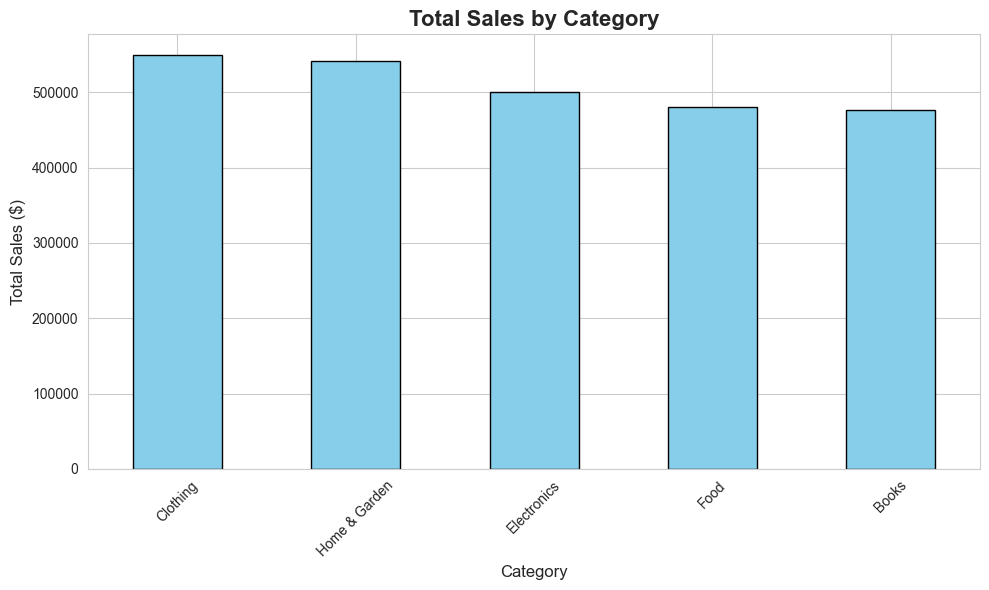

In [5]:
plt.figure(figsize=(10, 6))
category_sales = df.groupby(
    'Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Sales by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

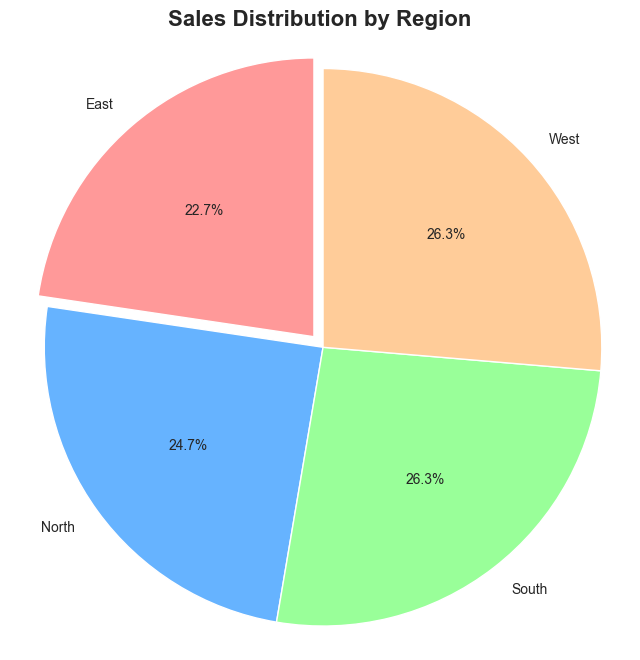

In [6]:
# Sales by Region - Pie Chart
plt.figure(figsize=(8, 8))
region_sales = df.groupby('Region')['Sales'].sum()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
        startangle=90, colors=colors, explode=(0.05, 0, 0, 0))
plt.title('Sales Distribution by Region', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

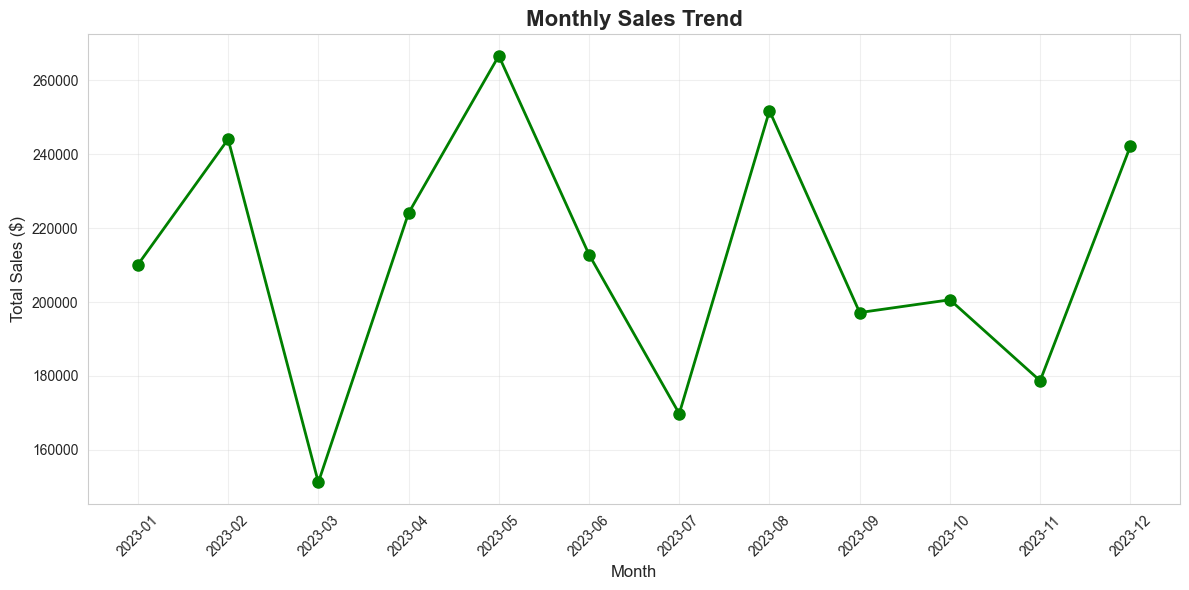

In [7]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values,
         marker='o', linewidth=2, color='green', markersize=8)
plt.title('Monthly Sales Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

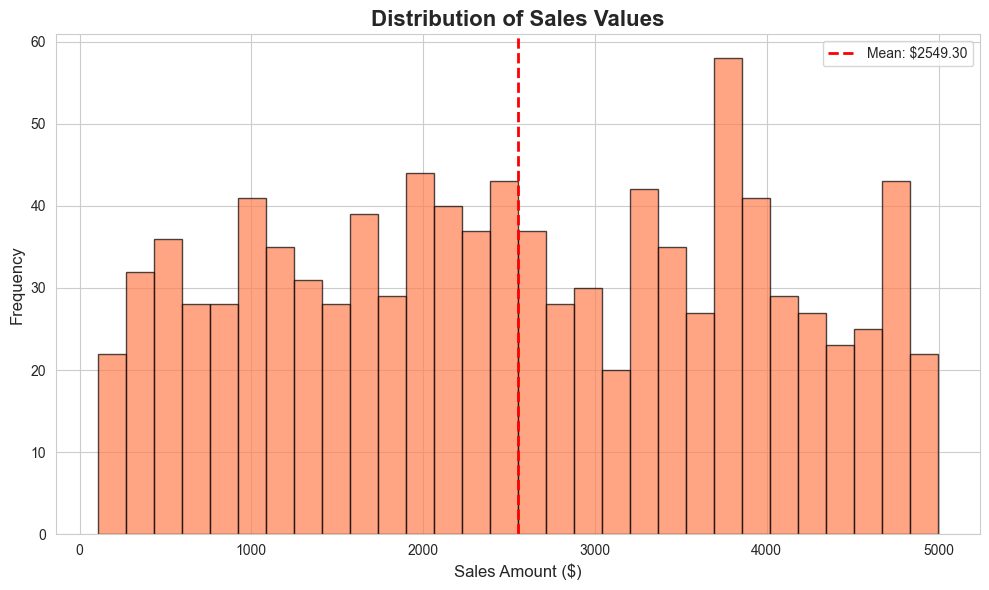

In [8]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=30, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sales Values', fontsize=16, fontweight='bold')
plt.xlabel('Sales Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['Sales'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: ${df["Sales"].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

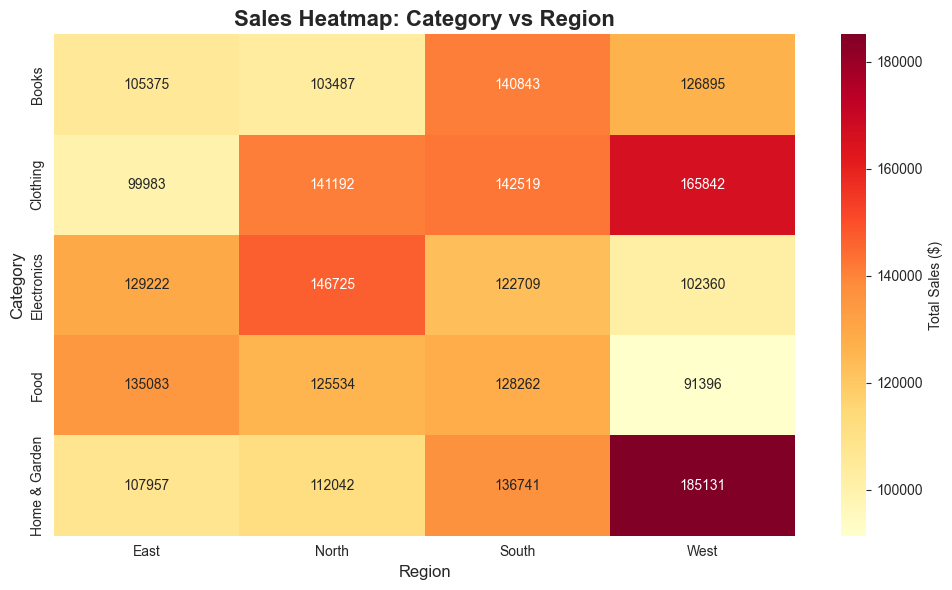

In [9]:
pivot_table = df.pivot_table(values='Sales', index='Category',
                             columns='Region', aggfunc='sum')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd',
            cbar_kws={'label': 'Total Sales ($)'})
plt.title('Sales Heatmap: Category vs Region', fontsize=16, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Key Insights

In [11]:
print("KEY INSIGHTS")

print(f"\n1. Total Revenue: ${df['Sales'].sum():,.2f}")
print(f"2. Average Transaction: ${df['Sales'].mean():.2f}")
print(f"3. Total Transactions: {len(df)}")

top_category = df.groupby('Category')['Sales'].sum().idxmax()
print(f"\n4. Best Performing Category: {top_category}")

top_region = df.groupby('Region')['Sales'].sum().idxmax()
print(f"5. Best Performing Region: {top_region}")

best_month = monthly_sales.idxmax()
print(f"6. Best Month: {best_month}")

print("\n" + "=" * 50)

KEY INSIGHTS

1. Total Revenue: $2,549,298.00
2. Average Transaction: $2549.30
3. Total Transactions: 1000

4. Best Performing Category: Clothing
5. Best Performing Region: West
6. Best Month: 2023-05

